In [1]:
import sys
sys.path.append("/home/ubuntu22/4761-project/src")

from spatial_mrf.model_HMRF import AW_HMRF

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

In [2]:
#toy embeddings

import numpy as np

np.random.seed(0)

# grid size
H, W = 20, 20
N = H * W
d = 2

coords = np.array([(i, j) for i in range(H) for j in range(W)])

# ground truth region
true_labels = np.zeros(N, dtype=int)

for i, (x, y) in enumerate(coords):
    if x < 10 and y < 10:
        true_labels[i] = 0
    elif x < 10 and y >= 10:
        true_labels[i] = 1
    else:
        true_labels[i] = 2

# embedding = region signal + noise
embeddings = np.zeros((N, d))

embeddings[true_labels == 0] = np.array([0, 0])
embeddings[true_labels == 1] = np.array([5, 0])
embeddings[true_labels == 2] = np.array([0, 5])

embeddings += np.random.normal(0, 2.0, embeddings.shape)

print(embeddings.shape, true_labels.shape)

(400, 2) (400,)


In [3]:
#graph construction
import scipy.sparse as sp

def build_grid_graph(H, W):
    N = H * W
    row, col, data = [], [], []

    def idx(x, y):
        return x * W + y

    for x in range(H):
        for y in range(W):
            i = idx(x, y)

            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < H and 0 <= ny < W:
                    j = idx(nx, ny)
                    row.append(i)
                    col.append(j)
                    data.append(1.0)

    W_mat = sp.csr_matrix((data, (row, col)), shape=(N, N))
    return W_mat

W = build_grid_graph(H, W)

print(W.shape, W.nnz)

(400, 400) 1520


In [4]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, n_init=10)
km_labels = km.fit_predict(embeddings)

In [5]:
from spatial_mrf.model_HMRF import AW_HMRF

results = {}

for beta in [0.0, 1.0, 5.0]:
    model = AW_HMRF(
        n_regions=3,
        beta=beta,
        max_em_iter=10,
        max_icm_iter=5,
    )

    res = model.fit(embeddings, W)
    results[beta] = res.states

    print("beta=", beta, "done")

beta= 0.0 done
beta= 1.0 done
beta= 5.0 done


In [6]:
#accuracy vs ground truth (with best label matching)
import numpy as np
from sklearn.metrics import accuracy_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

def calculate_metrics(pred, true):
    """
    Hungarian Algorithm for Best Label Matching and ARI Calculation
    """
    y_true = np.array(true)
    y_pred = np.array(pred)
    
    # 1.Best matching for accuracy (ACC)
    labels = np.unique(y_true)
    n_labels = len(labels)
    
    # constructing cost matrix for Hungarian algorithm
    cost_matrix = np.zeros((n_labels, n_labels))
    for i in range(n_labels):
        for j in range(n_labels):
            # cost is negative of the number of matches between true label i and predicted label j
            cost_matrix[i, j] = -np.sum((y_true == labels[i]) & (y_pred == labels[j]))
    
    # apply Hungarian algorithm to find the best label mapping
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    #   create mapping from predicted labels to true labels
    mapping = {labels[col_ind[i]]: labels[row_ind[i]] for i in range(n_labels)}
    mapped_pred = np.array([mapping[label] for label in y_pred])
    
    acc = accuracy_score(y_true, mapped_pred)
    
    # --- 2. Adjusted Rand Index (ARI) ---
    ari = adjusted_rand_score(y_true, y_pred)
    
    return acc, ari

# ==========================================
# 2. main evaluation loop
# ==========================================

# 2.1. Evaluate KMeans baseline
km_acc, km_ari = calculate_metrics(km_labels, true_labels)
print(f"KMeans 基准测试 -> ACC: {km_acc:.4f}, ARI: {km_ari:.4f}")
print("-" * 50)

# 2.2. Evaluate HMRF results for different beta values
for beta, pred in results.items():
    acc, ari = calculate_metrics(pred, true_labels)
    print(f"HMRF (beta={beta:3.1f}) -> ACC: {acc:.4f}, ARI: {ari:.4f}")

KMeans 基准测试 -> ACC: 0.8400, ARI: 0.5877
--------------------------------------------------
HMRF (beta=0.0) -> ACC: 0.8250, ARI: 0.5509
HMRF (beta=1.0) -> ACC: 0.9575, ARI: 0.8857
HMRF (beta=5.0) -> ACC: 1.0000, ARI: 1.0000


In [7]:
def spatial_coherence(labels, W):
    total = W.sum()
    same = 0

    coo = W.tocoo()
    for i, j in zip(coo.row, coo.col):
        if labels[i] == labels[j]:
            same += 1

    return same / total

print("KMeans coherence:", spatial_coherence(km_labels, W))

for beta, pred in results.items():
    print(f"HMRF beta={beta} coherence:", spatial_coherence(pred, W))

    """ # for large N
    def spatial_coherence_fast(labels, W):
    # 将 labels 转换为 numpy 数组
    labels = np.array(labels)
    # W 是邻接矩阵，W.tocoo() 拿到所有邻居索引
    coo = W.tocoo()
    # 一次性对比所有邻居对，直接求和
    same = np.sum(labels[coo.row] == labels[coo.col])
    return same / W.sum() """

KMeans coherence: 0.6894736842105263
HMRF beta=0.0 coherence: 0.6763157894736842
HMRF beta=1.0 coherence: 0.9013157894736842
HMRF beta=5.0 coherence: 0.9605263157894737


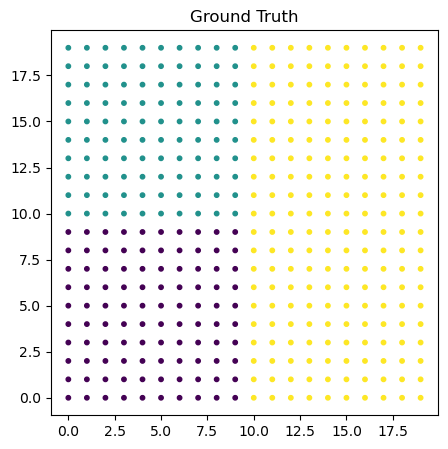

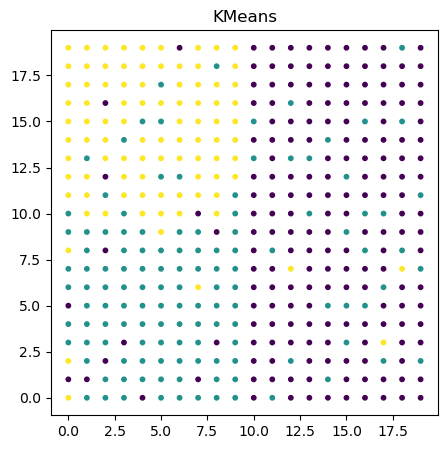

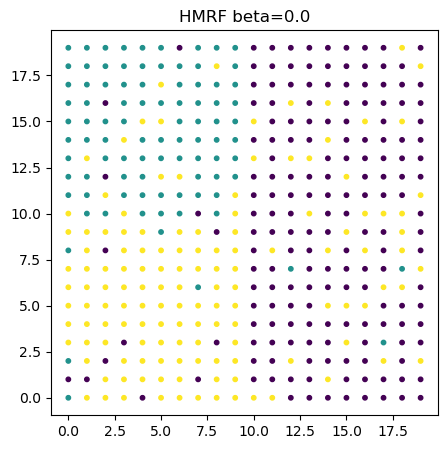

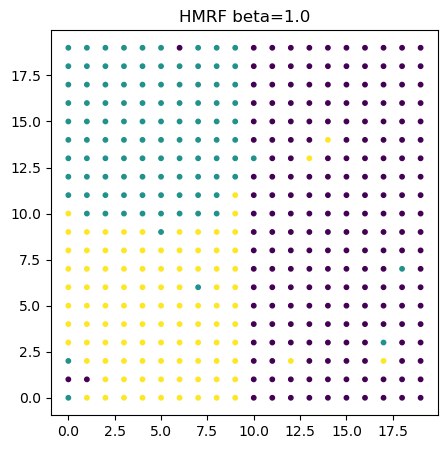

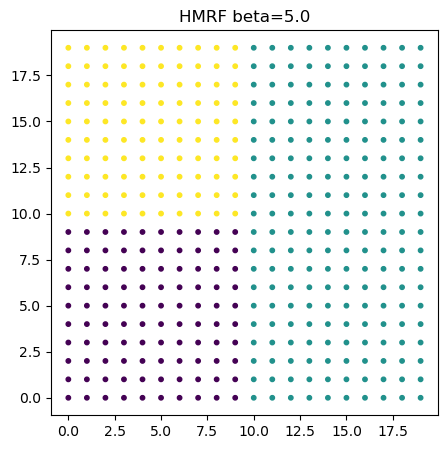

In [8]:
import matplotlib.pyplot as plt

def plot_labels(labels, title):
    plt.figure(figsize=(5,5))
    plt.scatter(coords[:,0], coords[:,1], c=labels, s=10)
    plt.title(title)
    plt.show()

plot_labels(true_labels, "Ground Truth")
plot_labels(km_labels, "KMeans")

for beta, pred in results.items():
    plot_labels(pred, f"HMRF beta={beta}")